<a href="https://colab.research.google.com/github/Kevin-Lucey/Algorithms/blob/main/Lucey_DataMining_Project_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub
import tensorflow as tf

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, make_scorer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [29]:
results = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scoring = {
    "accuracy": "accuracy",
    "precision_weighted": "precision_weighted",
    "recall_weighted": "recall_weighted",
    "f1_weighted": "f1_weighted",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "precision_positive": make_scorer(precision_score, pos_label=1, zero_division=0),
    "recall_positive": make_scorer(recall_score, pos_label=1, zero_division=0),
    "f1_positive": make_scorer(f1_score, pos_label=1, zero_division=0),
}

def run_cv_metrics(model, X, y):
    scores = cross_validate(model, X, y, cv=cv, scoring=cv_scoring, n_jobs=-1)
    out = {}
    for k, v in scores.items():
        if k.startswith("test_"):
            out[k.replace("test_", "CV_") + "_mean"] = v.mean()
            if k == "test_accuracy":
                out["CV_Accuracy_std"] = v.std()
    return out

def collect_metrics(model_name, y_true, y_pred, notes="", split="Test", **cv_metrics):
    row = {
        "Model": model_name,
        "Split": split,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "Precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Notes": notes,
        "Precision_positive": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Recall_positive": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "F1_positive": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
    }

    if set(np.unique(y_true)).issubset({0,1}) and set(np.unique(y_pred)).issubset({0,1}):
        row["Precision_negative"] = precision_score(y_true, y_pred, pos_label=0, zero_division=0)
        row["Recall_negative"] = recall_score(y_true, y_pred, pos_label=0, zero_division=0)
        row["F1_negative"] = f1_score(y_true, y_pred, pos_label=0, zero_division=0)
    else:
        row["Precision_negative"] = np.nan
        row["Recall_negative"] = np.nan
        row["F1_negative"] = np.nan

    row.update(cv_metrics)
    results.append(row)
    return pd.DataFrame(results)

def show_results(sort_by="Accuracy", ascending=False):
    df2 = pd.DataFrame(results)
    if sort_by in df2.columns:
        df2 = df2.sort_values(sort_by, ascending=ascending).reset_index(drop=True)
    return df2

In [30]:
path = kagglehub.dataset_download("bhanageviraj/buy-now-pay-later-bnpl-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'buy-now-pay-later-bnpl-dataset' dataset.
Path to dataset files: /kaggle/input/buy-now-pay-later-bnpl-dataset


In [31]:
files = os.listdir(path)
csv_file = [f for f in files if f.endswith(".csv")][0]
df = pd.read_csv(os.path.join(path, csv_file))
df.head()

,Transaction_ID,Customer_Age,Gender,Annual_Income,Credit_Score,Purchase_Category,BNPL_Provider,Purchase_Amount,Device_Type,Connection_Type,Checkout_Time_Seconds,Browser,Repayment_Status
0,705eef54-52b2-4912-b562-d9f7b4184a6d,56,Male,32293,353,Beauty,Sezzle,249,Tablet,WiFi,82,Firefox,Paid On Time
1,7dbe58a0-0177-4572-8f3a-566d907e9c56,46,Male,72774,354,Groceries,Affirm,188,Mobile,WiFi,60,Firefox,Paid On Time
2,b77e4be3-bf88-4bb0-addb-45d84e6a3f65,32,Male,82207,630,Travel,Sezzle,1610,Desktop,WiFi,86,Chrome,Paid On Time
3,5c3c24a8-675e-46fd-8312-4ac37cbb97c5,60,Male,92498,470,Fashion,Sezzle,120,Mobile,4G/5G,169,Chrome,Paid On Time
4,4bb92076-f15e-4cfc-8aac-58395d69aedc,25,Male,32060,502,Travel,Klarna,1849,Mobile,4G/5G,38,Chrome,Defaulted


In [32]:
df.columns

Index(['Transaction_ID', 'Customer_Age', 'Gender', 'Annual_Income',
       'Credit_Score', 'Purchase_Category', 'BNPL_Provider', 'Purchase_Amount',
       'Device_Type', 'Connection_Type', 'Checkout_Time_Seconds', 'Browser',
       'Repayment_Status'],
      dtype='object')

In [33]:
df.describe()

,Customer_Age,Annual_Income,Credit_Score,Purchase_Amount,Checkout_Time_Seconds
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,40.979240,69980.860200,573.569300,563.221980,92.103000
std,13.528733,28923.444012,158.853766,706.078491,50.762158
min,18.000000,20000.000000,300.000000,20.000000,5.000000
25%,29.000000,44915.500000,435.000000,124.000000,48.000000
50%,41.000000,70071.500000,572.000000,229.000000,92.000000
75%,53.000000,95262.250000,711.000000,785.000000,136.000000
max,64.000000,119998.000000,849.000000,2999.000000,179.000000


In [34]:
df['Purchase_Category'].unique()

array(['Beauty', 'Groceries', 'Travel', 'Fashion', 'Home & Furniture',
       'Electronics'], dtype=object)

In [35]:
df = pd.get_dummies(df, columns=['Purchase_Category'], drop_first=True)

In [36]:
df['Repayment_Status'].unique()

array(['Paid On Time', 'Defaulted', 'Late Payment'], dtype=object)

In [37]:
mapping = {
    'Paid On Time': 0,
    'Late Payment': 1,
    'Defaulted': 1
}

df['Repayment_Status_Encoded'] = df['Repayment_Status'].map(mapping)

df.drop(columns=['Repayment_Status'], inplace=True)

In [38]:
df['Gender'].unique()

array(['Male', 'Female', 'Non-Binary'], dtype=object)

In [39]:
df = pd.get_dummies(df, columns=['Gender'], drop_first=True)

In [40]:
df['BNPL_Provider'].unique()

array(['Sezzle', 'Affirm', 'Klarna', 'Afterpay'], dtype=object)

In [41]:
df.columns

Index(['Transaction_ID', 'Customer_Age', 'Annual_Income', 'Credit_Score',
       'BNPL_Provider', 'Purchase_Amount', 'Device_Type', 'Connection_Type',
       'Checkout_Time_Seconds', 'Browser', 'Purchase_Category_Electronics',
       'Purchase_Category_Fashion', 'Purchase_Category_Groceries',
       'Purchase_Category_Home & Furniture', 'Purchase_Category_Travel',
       'Repayment_Status_Encoded', 'Gender_Male', 'Gender_Non-Binary'],
      dtype='object')

In [42]:
for c in df.columns:
    print(c)

Transaction_ID
Customer_Age
Annual_Income
Credit_Score
BNPL_Provider
Purchase_Amount
Device_Type
Connection_Type
Checkout_Time_Seconds
Browser
Purchase_Category_Electronics
Purchase_Category_Fashion
Purchase_Category_Groceries
Purchase_Category_Home & Furniture
Purchase_Category_Travel
Repayment_Status_Encoded
Gender_Male
Gender_Non-Binary


In [43]:
df.head()

,Transaction_ID,Customer_Age,Annual_Income,Credit_Score,BNPL_Provider,Purchase_Amount,Device_Type,Connection_Type,Checkout_Time_Seconds,Browser,Purchase_Category_Electronics,Purchase_Category_Fashion,Purchase_Category_Groceries,Purchase_Category_Home & Furniture,Purchase_Category_Travel,Repayment_Status_Encoded,Gender_Male,Gender_Non-Binary
0,705eef54-52b2-4912-b562-d9f7b4184a6d,56,32293,353,Sezzle,249,Tablet,WiFi,82,Firefox,False,False,False,False,False,0,True,False
1,7dbe58a0-0177-4572-8f3a-566d907e9c56,46,72774,354,Affirm,188,Mobile,WiFi,60,Firefox,False,False,True,False,False,0,True,False
2,b77e4be3-bf88-4bb0-addb-45d84e6a3f65,32,82207,630,Sezzle,1610,Desktop,WiFi,86,Chrome,False,False,False,False,True,0,True,False
3,5c3c24a8-675e-46fd-8312-4ac37cbb97c5,60,92498,470,Sezzle,120,Mobile,4G/5G,169,Chrome,False,True,False,False,False,0,True,False
4,4bb92076-f15e-4cfc-8aac-58395d69aedc,25,32060,502,Klarna,1849,Mobile,4G/5G,38,Chrome,False,False,False,False,True,1,True,False


In [44]:
df = pd.get_dummies(df, columns=['BNPL_Provider', 'Browser', 'Device_Type', "Connection_Type"], drop_first=True)

Number of numerical features: 6
                          Customer_Age  Annual_Income  Credit_Score  \
Customer_Age                  1.000000       0.003454      0.002323   
Annual_Income                 0.003454       1.000000     -0.001350   
Credit_Score                  0.002323      -0.001350      1.000000   
Purchase_Amount               0.001382      -0.002282      0.008720   
Checkout_Time_Seconds        -0.001586      -0.010333      0.002024   
Repayment_Status_Encoded      0.004097      -0.032438     -0.252644   

                          Purchase_Amount  Checkout_Time_Seconds  \
Customer_Age                     0.001382              -0.001586   
Annual_Income                   -0.002282              -0.010333   
Credit_Score                     0.008720               0.002024   
Purchase_Amount                  1.000000              -0.001664   
Checkout_Time_Seconds           -0.001664               1.000000   
Repayment_Status_Encoded         0.000706              -0.0111

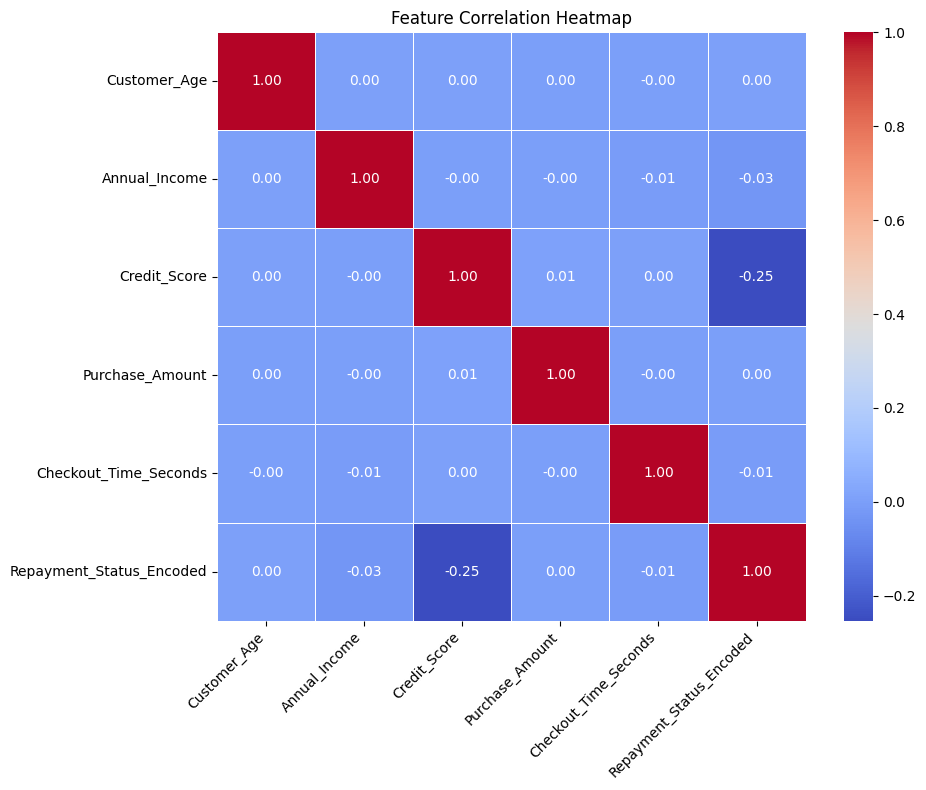

In [45]:
num_df = df.select_dtypes(include=['int64', 'float64'])

print("Number of numerical features:", num_df.shape[1])

corr_matrix = num_df.corr()
print(corr_matrix)

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title("Feature Correlation Heatmap")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

In [46]:
df['Income_per_Age'] = df['Annual_Income'] / (df['Customer_Age'] + 1)

df['Amount_to_Income'] = df['Purchase_Amount'] / (df['Annual_Income'] + 1)

df['Amount_to_Credit'] = df['Purchase_Amount'] / (df['Credit_Score'] + 1)

df['Credit_per_Age'] = df['Credit_Score'] / (df['Customer_Age'] + 1)

Number of numerical features: 10
                          Customer_Age  Annual_Income  Credit_Score  \
Customer_Age                  1.000000       0.003454      0.002323   
Annual_Income                 0.003454       1.000000     -0.001350   
Credit_Score                  0.002323      -0.001350      1.000000   
Purchase_Amount               0.001382      -0.002282      0.008720   
Checkout_Time_Seconds        -0.001586      -0.010333      0.002024   
Repayment_Status_Encoded      0.004097      -0.032438     -0.252644   
Income_per_Age               -0.610252       0.714937     -0.000415   
Amount_to_Income             -0.000777      -0.324123      0.007367   
Amount_to_Credit              0.002315      -0.001472     -0.211134   
Credit_per_Age               -0.743467      -0.001526      0.580591   

                          Purchase_Amount  Checkout_Time_Seconds  \
Customer_Age                     0.001382              -0.001586   
Annual_Income                   -0.002282        

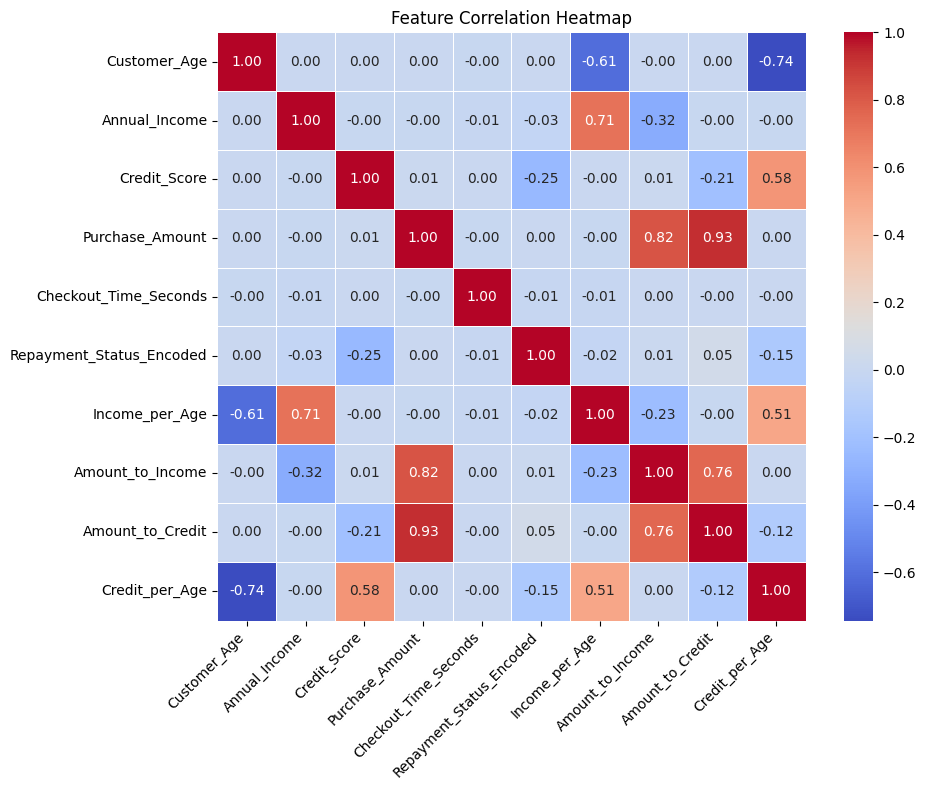

In [47]:
num_df = df.select_dtypes(include=['int64', 'float64'])

print("Number of numerical features:", num_df.shape[1])

corr_matrix = num_df.corr()
print(corr_matrix)

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title("Feature Correlation Heatmap")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

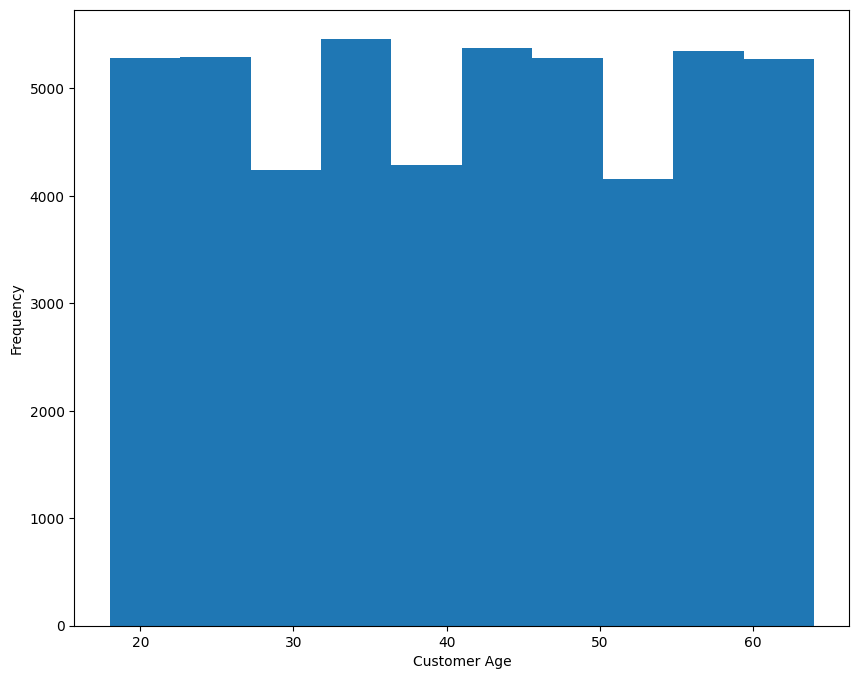

In [48]:
plt.figure(figsize=(10,8))
plt.hist(df['Customer_Age'])
plt.xlabel('Customer Age')
plt.ylabel('Frequency')
plt.show()

In [49]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData Types:\n", df.dtypes)

Shape: (50000, 28)

Columns:
 Index(['Transaction_ID', 'Customer_Age', 'Annual_Income', 'Credit_Score',
       'Purchase_Amount', 'Checkout_Time_Seconds',
       'Purchase_Category_Electronics', 'Purchase_Category_Fashion',
       'Purchase_Category_Groceries', 'Purchase_Category_Home & Furniture',
       'Purchase_Category_Travel', 'Repayment_Status_Encoded', 'Gender_Male',
       'Gender_Non-Binary', 'BNPL_Provider_Afterpay', 'BNPL_Provider_Klarna',
       'BNPL_Provider_Sezzle', 'Browser_Edge', 'Browser_Firefox',
       'Browser_Safari', 'Device_Type_Mobile', 'Device_Type_Tablet',
       'Connection_Type_VPN', 'Connection_Type_WiFi', 'Income_per_Age',
       'Amount_to_Income', 'Amount_to_Credit', 'Credit_per_Age'],
      dtype='object')

Data Types:
 Transaction_ID                         object
Customer_Age                            int64
Annual_Income                           int64
Credit_Score                            int64
Purchase_Amount                         int64
Check

In [50]:
X = df.drop(columns=['Repayment_Status_Encoded', "Transaction_ID"])
y = df['Repayment_Status_Encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [51]:
df.columns

Index(['Transaction_ID', 'Customer_Age', 'Annual_Income', 'Credit_Score',
       'Purchase_Amount', 'Checkout_Time_Seconds',
       'Purchase_Category_Electronics', 'Purchase_Category_Fashion',
       'Purchase_Category_Groceries', 'Purchase_Category_Home & Furniture',
       'Purchase_Category_Travel', 'Repayment_Status_Encoded', 'Gender_Male',
       'Gender_Non-Binary', 'BNPL_Provider_Afterpay', 'BNPL_Provider_Klarna',
       'BNPL_Provider_Sezzle', 'Browser_Edge', 'Browser_Firefox',
       'Browser_Safari', 'Device_Type_Mobile', 'Device_Type_Tablet',
       'Connection_Type_VPN', 'Connection_Type_WiFi', 'Income_per_Age',
       'Amount_to_Income', 'Amount_to_Credit', 'Credit_per_Age'],
      dtype='object')

Decision Tree TRAIN Accuracy: 0.6153
Decision Tree TEST Accuracy: 0.6149

Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.56      0.69      7680
           1       0.35      0.79      0.49      2320

    accuracy                           0.61     10000
   macro avg       0.62      0.68      0.59     10000
weighted avg       0.77      0.61      0.64     10000


Decision Tree Confusion Matrix:
 [[4322 3358]
 [ 493 1827]]

Decision Tree CV metrics: {'CV_accuracy_mean': np.float64(0.6112), 'CV_Accuracy_std': np.float64(0.00678813302757098), 'CV_precision_weighted_mean': np.float64(0.7696652597287972), 'CV_recall_weighted_mean': np.float64(0.6112), 'CV_f1_weighted_mean': np.float64(0.6407124964622992), 'CV_precision_macro_mean': np.float64(0.6231482874703083), 'CV_recall_macro_mean': np.float64(0.6724240508563029), 'CV_f1_macro_mean': np.float64(0.5861080673127003), 'CV_precision_positive_mean': np.float64(0.349770

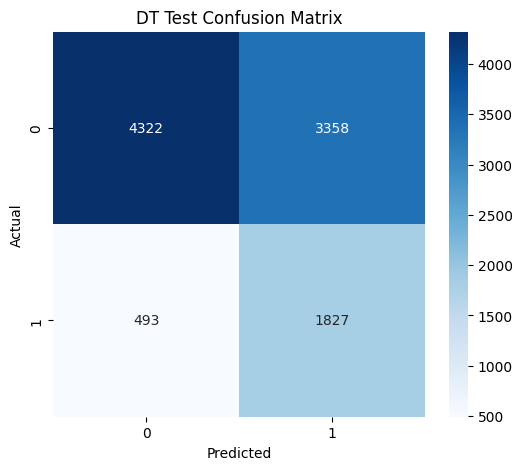

,Model,Split,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,Precision_macro,Recall_macro,F1_macro,Notes,Precision_positive,Recall_positive,F1_positive,Precision_negative,Recall_negative,F1_negative,cv_metrics
0,Decision Tree,Train,0.6153,0.776405,0.6153,0.644388,0.629261,0.680884,0.591253,balanced class weights,0.354713,0.803254,0.492112,0.903809,0.558514,0.690395,NaN
1,Decision Tree,Test,0.6149,0.771114,0.6149,0.644255,0.624987,0.675130,0.589336,balanced class weights,0.352363,0.787500,0.486875,0.897612,0.562760,0.691797,"{'CV_accuracy_mean': 0.6112, 'CV_Accuracy_std'..."


In [52]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

dt_model = DecisionTreeClassifier(
    criterion='log_loss',
    max_depth=7,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced'
)

dt_cv_metrics = run_cv_metrics(dt_model, X_train, y_train)

dt_model.fit(X_train, y_train)

y_pred_dt_train = dt_model.predict(X_train)
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree TRAIN Accuracy:", accuracy_score(y_train, y_pred_dt_train))
print("Decision Tree TEST Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nDecision Tree Classification Report:\n", classification_report(y_test, y_pred_dt, zero_division=0))
print("\nDecision Tree Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("\nDecision Tree CV metrics:", dt_cv_metrics)

cm = confusion_matrix(y_test, y_pred_dt)
print("\nConfusion Matrix:\n", cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('DT Test Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

collect_metrics("Decision Tree", y_train, y_pred_dt_train, notes="balanced class weights", split="Train")
results_df = collect_metrics("Decision Tree", y_test, y_pred_dt, notes="balanced class weights", split="Test", cv_metrics=dt_cv_metrics)
show_results()

Random Forest TRAIN Accuracy: 0.8157003808717732
Random Forest TEST Accuracy: 0.744

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.86      0.84      7680
           1       0.44      0.35      0.39      2320

    accuracy                           0.74     10000
   macro avg       0.63      0.61      0.61     10000
weighted avg       0.73      0.74      0.73     10000


Random Forest Confusion Matrix:
 [[6618 1062]
 [1498  822]]

Random Forest CV metrics: {'CV_accuracy_mean': np.float64(0.7412750000000001), 'CV_Accuracy_std': np.float64(0.006015812497078014), 'CV_precision_weighted_mean': np.float64(0.7251330084795974), 'CV_recall_weighted_mean': np.float64(0.7412750000000001), 'CV_f1_weighted_mean': np.float64(0.7318191345843299), 'CV_precision_macro_mean': np.float64(0.6221435853909989), 'CV_recall_macro_mean': np.float64(0.6053332143075495), 'CV_f1_macro_mean': np.float64(0.6114500854589521), 'CV_precision

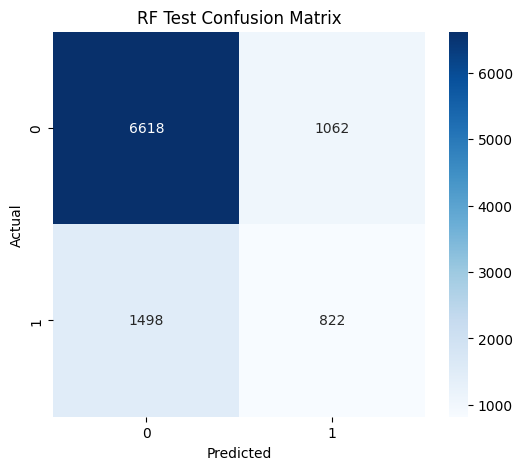

,Model,Split,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,Precision_macro,Recall_macro,F1_macro,Notes,Precision_positive,Recall_positive,F1_positive,Precision_negative,Recall_negative,F1_negative,cv_metrics
0,Random Forest,Train,0.8157,0.819693,0.8157,0.815123,0.819693,0.815700,0.815123,SMOTE on training set,0.855420,0.759823,0.804793,0.783966,0.871578,0.825454,NaN
1,Random Forest,Test,0.7440,0.727470,0.7440,0.734258,0.625866,0.608015,0.614495,SMOTE on training set,0.436306,0.354310,0.391056,0.815426,0.861719,0.837934,"{'CV_accuracy_mean': 0.7412750000000001, 'CV_A..."
2,Decision Tree,Train,0.6153,0.776405,0.6153,0.644388,0.629261,0.680884,0.591253,balanced class weights,0.354713,0.803254,0.492112,0.903809,0.558514,0.690395,NaN
3,Decision Tree,Test,0.6149,0.771114,0.6149,0.644255,0.624987,0.675130,0.589336,balanced class weights,0.352363,0.787500,0.486875,0.897612,0.562760,0.691797,"{'CV_accuracy_mean': 0.6112, 'CV_Accuracy_std'..."


In [53]:
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_model = RandomForestClassifier(
    n_estimators=100,
    criterion='entropy',
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_cv_pipe = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", rf_model)
])
rf_cv_metrics = run_cv_metrics(rf_cv_pipe, X_train, y_train)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

rf_model.fit(X_train_smote, y_train_smote)

y_pred_rf_train = rf_model.predict(X_train_smote)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest TRAIN Accuracy:", accuracy_score(y_train_smote, y_pred_rf_train))
print("Random Forest TEST Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nRandom Forest Classification Report:\n", classification_report(y_test, y_pred_rf, zero_division=0))
print("\nRandom Forest Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nRandom Forest CV metrics:", rf_cv_metrics)

cm = confusion_matrix(y_test, y_pred_rf)
print("\nConfusion Matrix:\n", cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('RF Test Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

collect_metrics("Random Forest", y_train_smote, y_pred_rf_train, notes="SMOTE on training set", split="Train")
results_df = collect_metrics("Random Forest", y_test, y_pred_rf, notes="SMOTE on training set", split="Test", cv_metrics=rf_cv_metrics)
show_results()

In [54]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
print(num_cols)

X = df.drop(columns=['Repayment_Status_Encoded', "Transaction_ID"])
y = df['Repayment_Status_Encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

X_test[num_cols] = scaler.transform(X_test[num_cols])

Index(['Customer_Age', 'Annual_Income', 'Credit_Score', 'Purchase_Amount',
       'Checkout_Time_Seconds', 'Income_per_Age', 'Amount_to_Income',
       'Amount_to_Credit', 'Credit_per_Age'],
      dtype='object')


In [55]:
X_train[num_cols].describe()

,Customer_Age,Annual_Income,Credit_Score,Purchase_Amount,Checkout_Time_Seconds,Income_per_Age,Amount_to_Income,Amount_to_Credit,Credit_per_Age
count,4.000000e+04,4.000000e+04,4.000000e+04,4.000000e+04,4.000000e+04,4.000000e+04,4.000000e+04,4.000000e+04,4.000000e+04
mean,7.318590e-17,2.010836e-16,-2.092548e-16,6.927792e-17,1.347367e-16,-1.200817e-16,3.197442e-17,1.207923e-17,-2.307488e-16
std,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00
min,-1.701264e+00,-1.723433e+00,-1.720610e+00,-7.668983e-01,-1.713936e+00,-1.441947e+00,-6.389137e-01,-7.268944e-01,-1.474666e+00
25%,-8.870922e-01,-8.671590e-01,-8.697741e-01,-6.190712e-01,-8.668245e-01,-7.456170e-01,-5.358783e-01,-5.926404e-01,-7.288057e-01
50%,1.095431e-03,2.432457e-03,-1.263555e-02,-4.712441e-01,-1.280517e-05,-1.974922e-01,-4.224224e-01,-4.596539e-01,-2.432273e-01
75%,8.892831e-01,8.726457e-01,8.697130e-01,3.020052e-01,8.667988e-01,4.818073e-01,9.024978e-02,1.950838e-01,4.886130e-01
max,1.703455e+00,1.731199e+00,1.739457e+00,3.467494e+00,1.713910e+00,4.073841e+00,8.465512e+00,6.229131e+00,4.006815e+00



Feature Importance:
 Credit_Score                          0.151621
Credit_per_Age                        0.097731
Annual_Income                         0.089180
Income_per_Age                        0.086614
Amount_to_Credit                      0.086221
Amount_to_Income                      0.084186
Checkout_Time_Seconds                 0.084125
Purchase_Amount                       0.080220
Customer_Age                          0.064148
Connection_Type_VPN                   0.029952
Gender_Male                           0.013740
Device_Type_Mobile                    0.013475
Browser_Edge                          0.011235
BNPL_Provider_Afterpay                0.011030
Browser_Safari                        0.010897
Browser_Firefox                       0.010636
BNPL_Provider_Klarna                  0.010037
Connection_Type_WiFi                  0.009984
BNPL_Provider_Sezzle                  0.009881
Purchase_Category_Fashion             0.008069
Purchase_Category_Groceries           

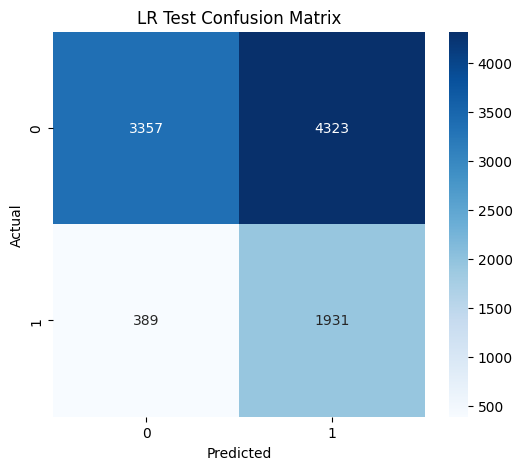

,Model,Split,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,Precision_macro,Recall_macro,F1_macro,Notes,Precision_positive,Recall_positive,F1_positive,Precision_negative,Recall_negative,F1_negative,cv_metrics
0,Random Forest,Train,0.815700,0.819693,0.815700,0.815123,0.819693,0.815700,0.815123,SMOTE on training set,0.855420,0.759823,0.804793,0.783966,0.871578,0.825454,NaN
1,Random Forest,Test,0.744000,0.727470,0.744000,0.734258,0.625866,0.608015,0.614495,SMOTE on training set,0.436306,0.354310,0.391056,0.815426,0.861719,0.837934,"{'CV_accuracy_mean': 0.7412750000000001, 'CV_A..."
2,Decision Tree,Train,0.615300,0.776405,0.615300,0.644388,0.629261,0.680884,0.591253,balanced class weights,0.354713,0.803254,0.492112,0.903809,0.558514,0.690395,NaN
3,Decision Tree,Test,0.614900,0.771114,0.614900,0.644255,0.624987,0.675130,0.589336,balanced class weights,0.352363,0.787500,0.486875,0.897612,0.562760,0.691797,"{'CV_accuracy_mean': 0.6112, 'CV_Accuracy_std'..."
4,Logistic Regression,Test,0.528800,0.759881,0.528800,0.555782,0.602459,0.634718,0.519019,"top_3_RF_features, threshold=0.4",0.308762,0.832328,0.450432,0.896156,0.437109,0.587607,"{'CV_accuracy_mean': 0.6343249999999999, 'CV_A..."
5,Logistic Regression,Train,0.521925,0.758314,0.521925,0.548266,0.600373,0.630844,0.513067,"top_3_RF_features, threshold=0.4",0.305678,0.834070,0.447392,0.895067,0.427618,0.578742,NaN


In [56]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

importance = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("\nFeature Importance:\n", importance)

top_k = 3
selected_features = importance.head(top_k).index.tolist()
print("\nSelected features:", selected_features)

X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

scaler = StandardScaler()
X_train_sel = scaler.fit_transform(X_train_sel)
X_test_sel = scaler.transform(X_test_sel)

log_model = LogisticRegression(
    solver='lbfgs',
    max_iter=5000,
    class_weight='balanced',
    random_state=42
)

log_cv_metrics = run_cv_metrics(log_model, X_train_sel, y_train)

log_model.fit(X_train_sel, y_train)

y_prob_train = log_model.predict_proba(X_train_sel)[:, 1]
y_pred_train = (y_prob_train >= 0.4).astype(int)

y_prob = log_model.predict_proba(X_test_sel)[:, 1]
y_pred = (y_prob >= 0.4).astype(int)

print("\nImproved Logistic Regression TRAIN Accuracy:", accuracy_score(y_train, y_pred_train))
print("Improved Logistic Regression TEST Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))
print("\nLogistic Regression CV metrics:", log_cv_metrics)

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('LR Test Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

collect_metrics("Logistic Regression", y_train, y_pred_train, notes="top_3_RF_features, threshold=0.4", split="Train")
results_df = collect_metrics("Logistic Regression", y_test, y_pred, notes="top_3_RF_features, threshold=0.4", split="Test", cv_metrics=log_cv_metrics)
show_results()

KNN TRAIN Accuracy: 1.0
KNN TEST Accuracy: 0.7435

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.91      0.85      7680
           1       0.39      0.18      0.25      2320

    accuracy                           0.74     10000
   macro avg       0.59      0.55      0.55     10000
weighted avg       0.69      0.74      0.71     10000


Confusion Matrix:
 [[7011  669]
 [1896  424]]

KNN CV metrics: {'CV_accuracy_mean': np.float64(0.7415), 'CV_Accuracy_std': np.float64(0.0039258756984907285), 'CV_precision_weighted_mean': np.float64(0.6924098854547506), 'CV_recall_weighted_mean': np.float64(0.7415), 'CV_f1_weighted_mean': np.float64(0.7052526252884821), 'CV_precision_macro_mean': np.float64(0.5837582801211478), 'CV_recall_macro_mean': np.float64(0.5461895336040055), 'CV_f1_macro_mean': np.float64(0.5450064147314511), 'CV_precision_positive_mean': np.float64(0.3810307807568279), 'CV_recall_positive_mean': np.float64(0.181769

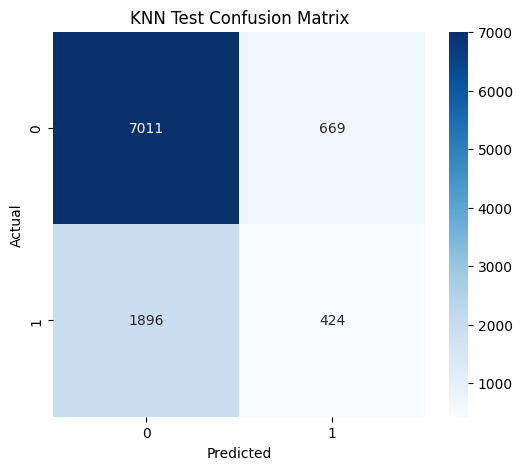

,Model,Split,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,Precision_macro,Recall_macro,F1_macro,Notes,Precision_positive,Recall_positive,F1_positive,Precision_negative,Recall_negative,F1_negative,cv_metrics
0,k-NN,Train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,scaled features,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN
1,Random Forest,Train,0.815700,0.819693,0.815700,0.815123,0.819693,0.815700,0.815123,SMOTE on training set,0.855420,0.759823,0.804793,0.783966,0.871578,0.825454,NaN
2,Random Forest,Test,0.744000,0.727470,0.744000,0.734258,0.625866,0.608015,0.614495,SMOTE on training set,0.436306,0.354310,0.391056,0.815426,0.861719,0.837934,"{'CV_accuracy_mean': 0.7412750000000001, 'CV_A..."
3,k-NN,Test,0.743500,0.694517,0.743500,0.706880,0.587528,0.547825,0.546911,scaled features,0.387923,0.182759,0.248462,0.787134,0.912891,0.845361,"{'CV_accuracy_mean': 0.7415, 'CV_Accuracy_std'..."
4,Decision Tree,Train,0.615300,0.776405,0.615300,0.644388,0.629261,0.680884,0.591253,balanced class weights,0.354713,0.803254,0.492112,0.903809,0.558514,0.690395,NaN
5,Decision Tree,Test,0.614900,0.771114,0.614900,0.644255,0.624987,0.675130,0.589336,balanced class weights,0.352363,0.787500,0.486875,0.897612,0.562760,0.691797,"{'CV_accuracy_mean': 0.6112, 'CV_Accuracy_std'..."
6,Logistic Regression,Test,0.528800,0.759881,0.528800,0.555782,0.602459,0.634718,0.519019,"top_3_RF_features, threshold=0.4",0.308762,0.832328,0.450432,0.896156,0.437109,0.587607,"{'CV_accuracy_mean': 0.6343249999999999, 'CV_A..."
7,Logistic Regression,Train,0.521925,0.758314,0.521925,0.548266,0.600373,0.630844,0.513067,"top_3_RF_features, threshold=0.4",0.305678,0.834070,0.447392,0.895067,0.427618,0.578742,NaN


In [57]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

knn_model = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance',
    metric='euclidean',
    p=2
)

knn_cv_metrics = run_cv_metrics(knn_model, X_train, y_train)

knn_model.fit(X_train, y_train)

y_pred_knn_train = knn_model.predict(X_train)
y_pred_knn = knn_model.predict(X_test)

print("KNN TRAIN Accuracy:", accuracy_score(y_train, y_pred_knn_train))
print("KNN TEST Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn, zero_division=0))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("\nKNN CV metrics:", knn_cv_metrics)

cm = confusion_matrix(y_test, y_pred_knn)
print("\nConfusion Matrix:\n", cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('KNN Test Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

collect_metrics("k-NN", y_train, y_pred_knn_train, notes="scaled features", split="Train")
results_df = collect_metrics("k-NN", y_test, y_pred_knn, notes="scaled features", split="Test", cv_metrics=knn_cv_metrics)
show_results()

Naive Bayes TRAIN Accuracy: 0.74365
Naive Bayes TEST Accuracy: 0.7445

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.90      0.84      7680
           1       0.41      0.24      0.30      2320

    accuracy                           0.74     10000
   macro avg       0.60      0.57      0.57     10000
weighted avg       0.71      0.74      0.72     10000


Confusion Matrix:
 [[6885  795]
 [1760  560]]

Naive Bayes CV metrics: {'CV_accuracy_mean': np.float64(0.7428750000000001), 'CV_Accuracy_std': np.float64(0.0025896428325156958), 'CV_precision_weighted_mean': np.float64(0.7055074471164712), 'CV_recall_weighted_mean': np.float64(0.7428750000000001), 'CV_f1_weighted_mean': np.float64(0.7167521703300899), 'CV_precision_macro_mean': np.float64(0.601502166702157), 'CV_recall_macro_mean': np.float64(0.566859211740675), 'CV_f1_macro_mean': np.float64(0.5715608616111544), 'CV_precision_positive_mean': np.float64(0.407444082090522

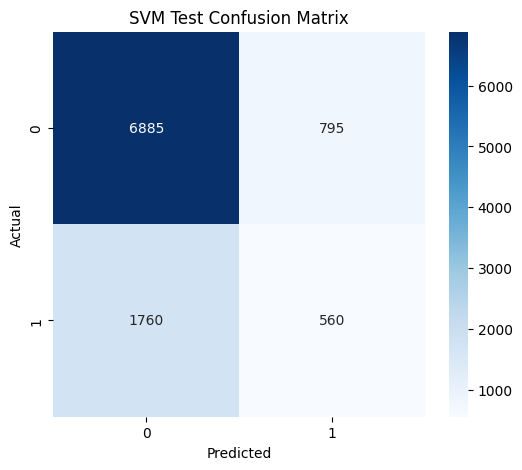

,Model,Split,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,Precision_macro,Recall_macro,F1_macro,Notes,Precision_positive,Recall_positive,F1_positive,Precision_negative,Recall_negative,F1_negative,cv_metrics
0,k-NN,Train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,scaled features,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN
1,Random Forest,Train,0.815700,0.819693,0.815700,0.815123,0.819693,0.815700,0.815123,SMOTE on training set,0.855420,0.759823,0.804793,0.783966,0.871578,0.825454,NaN
2,Naive Bayes,Test,0.744500,0.707528,0.744500,0.718506,0.604849,0.568932,0.574127,GaussianNB,0.413284,0.241379,0.304762,0.796414,0.896484,0.843492,"{'CV_accuracy_mean': 0.7428750000000001, 'CV_A..."
3,Random Forest,Test,0.744000,0.727470,0.744000,0.734258,0.625866,0.608015,0.614495,SMOTE on training set,0.436306,0.354310,0.391056,0.815426,0.861719,0.837934,"{'CV_accuracy_mean': 0.7412750000000001, 'CV_A..."
4,Naive Bayes,Train,0.743650,0.706079,0.743650,0.717262,0.602658,0.567139,0.571988,GaussianNB,0.409690,0.237798,0.300927,0.795626,0.896481,0.843048,NaN
5,k-NN,Test,0.743500,0.694517,0.743500,0.706880,0.587528,0.547825,0.546911,scaled features,0.387923,0.182759,0.248462,0.787134,0.912891,0.845361,"{'CV_accuracy_mean': 0.7415, 'CV_Accuracy_std'..."
6,Decision Tree,Train,0.615300,0.776405,0.615300,0.644388,0.629261,0.680884,0.591253,balanced class weights,0.354713,0.803254,0.492112,0.903809,0.558514,0.690395,NaN
7,Decision Tree,Test,0.614900,0.771114,0.614900,0.644255,0.624987,0.675130,0.589336,balanced class weights,0.352363,0.787500,0.486875,0.897612,0.562760,0.691797,"{'CV_accuracy_mean': 0.6112, 'CV_Accuracy_std'..."
8,Logistic Regression,Test,0.528800,0.759881,0.528800,0.555782,0.602459,0.634718,0.519019,"top_3_RF_features, threshold=0.4",0.308762,0.832328,0.450432,0.896156,0.437109,0.587607,"{'CV_accuracy_mean': 0.6343249999999999, 'CV_A..."
9,Logistic Regression,Train,0.521925,0.758314,0.521925,0.548266,0.600373,0.630844,0.513067,"top_3_RF_features, threshold=0.4",0.305678,0.834070,0.447392,0.895067,0.427618,0.578742,NaN


In [58]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nb_model = GaussianNB()

nb_cv_metrics = run_cv_metrics(nb_model, X_train, y_train)

nb_model.fit(X_train, y_train)

y_pred_nb_train = nb_model.predict(X_train)
y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes TRAIN Accuracy:", accuracy_score(y_train, y_pred_nb_train))
print("Naive Bayes TEST Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb, zero_division=0))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("\nNaive Bayes CV metrics:", nb_cv_metrics)

cm = confusion_matrix(y_test, y_pred_nb)
print("\nConfusion Matrix:\n", cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('SVM Test Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

collect_metrics("Naive Bayes", y_train, y_pred_nb_train, notes="GaussianNB", split="Train")
results_df = collect_metrics("Naive Bayes", y_test, y_pred_nb, notes="GaussianNB", split="Test", cv_metrics=nb_cv_metrics)
show_results()

Train PCA shape: (5000, 20)
Test PCA shape: (10000, 20)
[LibSVM]SVM TRAIN Accuracy: 0.6992
SVM TEST Accuracy: 0.6515
              precision    recall  f1-score   support

           0       0.85      0.66      0.74      7680
           1       0.36      0.62      0.45      2320

    accuracy                           0.65     10000
   macro avg       0.60      0.64      0.60     10000
weighted avg       0.74      0.65      0.68     10000


SVM CV metrics: {'CV_accuracy_mean': np.float64(0.648), 'CV_Accuracy_std': np.float64(0.013130118049735894), 'CV_precision_weighted_mean': np.float64(0.7349734168239065), 'CV_recall_weighted_mean': np.float64(0.648), 'CV_f1_weighted_mean': np.float64(0.6739043539074527), 'CV_precision_macro_mean': np.float64(0.5987334613452809), 'CV_recall_macro_mean': np.float64(0.6343427043352429), 'CV_f1_macro_mean': np.float64(0.5924975130462299), 'CV_precision_positive_mean': np.float64(0.3471832816376141), 'CV_recall_positive_mean': np.float64(0.60910955002847

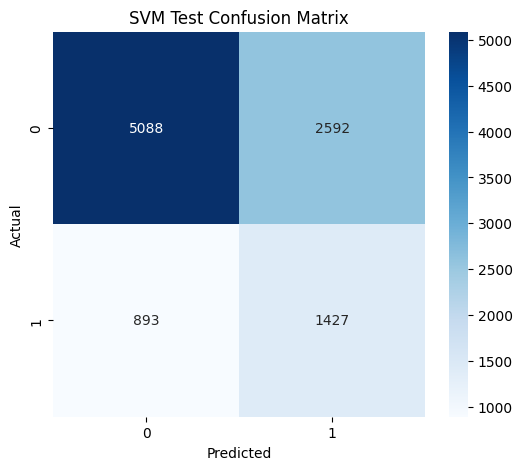

,Model,Split,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,Precision_macro,Recall_macro,F1_macro,Notes,Precision_positive,Recall_positive,F1_positive,Precision_negative,Recall_negative,F1_negative,cv_metrics
0,k-NN,Train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,scaled features,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN
1,Random Forest,Train,0.815700,0.819693,0.815700,0.815123,0.819693,0.815700,0.815123,SMOTE on training set,0.855420,0.759823,0.804793,0.783966,0.871578,0.825454,NaN
2,Naive Bayes,Test,0.744500,0.707528,0.744500,0.718506,0.604849,0.568932,0.574127,GaussianNB,0.413284,0.241379,0.304762,0.796414,0.896484,0.843492,"{'CV_accuracy_mean': 0.7428750000000001, 'CV_A..."
3,Random Forest,Test,0.744000,0.727470,0.744000,0.734258,0.625866,0.608015,0.614495,SMOTE on training set,0.436306,0.354310,0.391056,0.815426,0.861719,0.837934,"{'CV_accuracy_mean': 0.7412750000000001, 'CV_A..."
4,Naive Bayes,Train,0.743650,0.706079,0.743650,0.717262,0.602658,0.567139,0.571988,GaussianNB,0.409690,0.237798,0.300927,0.795626,0.896481,0.843048,NaN
5,k-NN,Test,0.743500,0.694517,0.743500,0.706880,0.587528,0.547825,0.546911,scaled features,0.387923,0.182759,0.248462,0.787134,0.912891,0.845361,"{'CV_accuracy_mean': 0.7415, 'CV_Accuracy_std'..."
6,SVM,Train,0.699200,0.782718,0.699200,0.721407,0.652137,0.707084,0.651965,"RBF kernel, PCA n_components=20, train subset=...",0.411034,0.721640,0.523749,0.893240,0.692527,0.780181,NaN
7,SVM,Test,0.651500,0.735708,0.651500,0.676532,0.602879,0.638793,0.597561,"RBF kernel, PCA n_components=20, train subset=...",0.355063,0.615086,0.450229,0.850694,0.662500,0.744894,"{'CV_accuracy_mean': 0.648, 'CV_Accuracy_std':..."
8,Decision Tree,Train,0.615300,0.776405,0.615300,0.644388,0.629261,0.680884,0.591253,balanced class weights,0.354713,0.803254,0.492112,0.903809,0.558514,0.690395,NaN
9,Decision Tree,Test,0.614900,0.771114,0.614900,0.644255,0.624987,0.675130,0.589336,balanced class weights,0.352363,0.787500,0.486875,0.897612,0.562760,0.691797,"{'CV_accuracy_mean': 0.6112, 'CV_Accuracy_std'..."


In [59]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X_train_small = X_train.iloc[:5000].copy() if hasattr(X_train, "iloc") else X_train[:5000]
y_train_small = y_train.iloc[:5000].copy() if hasattr(y_train, "iloc") else y_train[:5000]

X_test_small = X_test.copy() if hasattr(X_test, "copy") else X_test
y_test_small = y_test.copy() if hasattr(y_test, "copy") else y_test

svm_cv_pipe = Pipeline([
    ("pca", PCA(n_components=20)),
    ("model", SVC(kernel='rbf', class_weight='balanced'))
])
svm_cv_metrics = run_cv_metrics(svm_cv_pipe, X_train_small, y_train_small)

pca = PCA(n_components=20)
X_train_small_pca = pca.fit_transform(X_train_small)
X_test_small_pca = pca.transform(X_test_small)

print("Train PCA shape:", X_train_small_pca.shape)
print("Test PCA shape:", X_test_small_pca.shape)

svm_model = SVC(kernel='rbf', class_weight='balanced', verbose=True)
svm_model.fit(X_train_small_pca, y_train_small)

y_pred_train = svm_model.predict(X_train_small_pca)
y_pred = svm_model.predict(X_test_small_pca)

print("SVM TRAIN Accuracy:", accuracy_score(y_train_small, y_pred_train))
print("SVM TEST Accuracy:", accuracy_score(y_test_small, y_pred))
print(classification_report(y_test_small, y_pred, zero_division=0))
print("\nSVM CV metrics:", svm_cv_metrics)
print("\nConfusion Matrix:\n", confusion_matrix(y_test_small, y_pred))

cm = confusion_matrix(y_test_small, y_pred)
print("\nConfusion Matrix:\n", cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('SVM Test Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

collect_metrics("SVM", y_train_small, y_pred_train, notes="RBF kernel, PCA n_components=20, train subset=5000", split="Train")
results_df = collect_metrics("SVM", y_test_small, y_pred, notes="RBF kernel, PCA n_components=20, train subset=5000", split="Test", cv_metrics=svm_cv_metrics)
show_results()

Train distribution before SMOTE: [24575  7425]
Validation distribution: [6144 1856]
Test distribution: [7680 2320]
Train distribution after SMOTE: [24575 24575]
Epoch 1/100
768/768 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.6208 - loss: 0.6653 - val_accuracy: 0.6087 - val_loss: 0.6563
Epoch 2/100
768/768 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6561 - loss: 0.6287 - val_accuracy: 0.6176 - val_loss: 0.6503
Epoch 3/100
768/768 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6654 - loss: 0.6153 - val_accuracy: 0.6401 - val_loss: 0.6392
Epoch 4/100
768/768 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6735 - loss: 0.6062 - val_accuracy: 0.6345 - val_loss: 0.6427
Epoch 5/100
768/768 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6794 - loss: 0.5990 - val_accuracy: 0.6470 - val_loss: 0.6228
Epoch 6/100
768/768 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6886 - loss: 0.5883 - val_accuracy: 0.6325 - val_loss: 0.6394
Epoch 7/100
768/768 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy

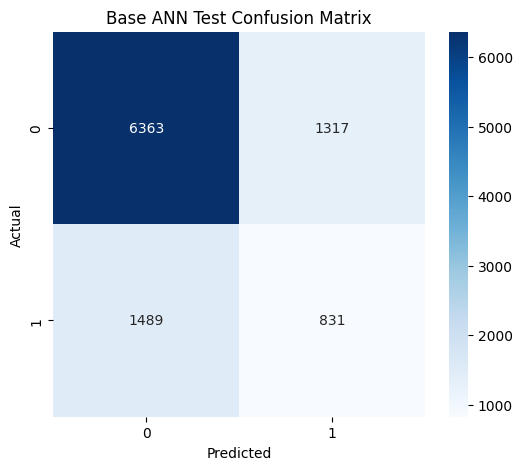

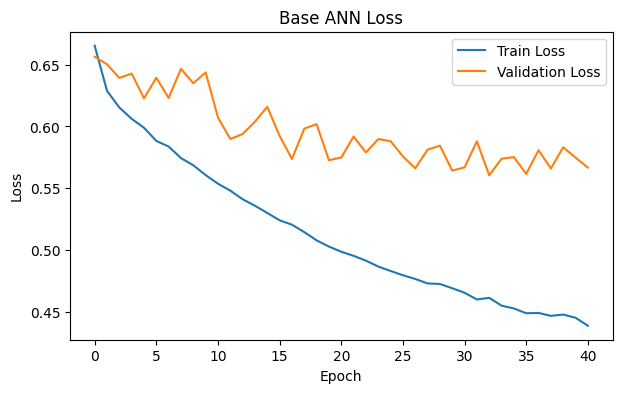

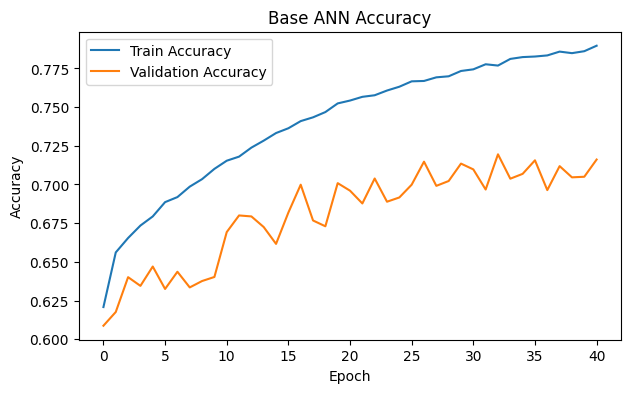

,Model,Split,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,Precision_macro,Recall_macro,F1_macro,Notes,Precision_positive,Recall_positive,F1_positive,Precision_negative,Recall_negative,F1_negative,cv_metrics
0,k-NN,Train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,scaled features,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN
1,ANN (Binary),Train,0.862319,0.863978,0.862319,0.862162,0.863978,0.862319,0.862162,SMOTE + tuned ANN; CV not run,0.888549,0.828566,0.857510,0.839407,0.896073,0.866815,NaN
2,ANN (Binary),Train,0.846551,0.850065,0.846551,0.846165,0.850065,0.846551,0.846165,SMOTE + tuned ANN; CV not run,0.885135,0.796460,0.838460,0.814994,0.896643,0.853871,NaN
3,ANN (Base),Train,0.843988,0.845445,0.843988,0.843823,0.845445,0.843988,0.843823,SMOTE + tuned ANN; CV not run,0.867879,0.811516,0.838752,0.823010,0.876460,0.848894,NaN
4,Random Forest,Train,0.815700,0.819693,0.815700,0.815123,0.819693,0.815700,0.815123,SMOTE on training set,0.855420,0.759823,0.804793,0.783966,0.871578,0.825454,NaN
5,Naive Bayes,Test,0.744500,0.707528,0.744500,0.718506,0.604849,0.568932,0.574127,GaussianNB,0.413284,0.241379,0.304762,0.796414,0.896484,0.843492,"{'CV_accuracy_mean': 0.7428750000000001, 'CV_A..."
6,Random Forest,Test,0.744000,0.727470,0.744000,0.734258,0.625866,0.608015,0.614495,SMOTE on training set,0.436306,0.354310,0.391056,0.815426,0.861719,0.837934,"{'CV_accuracy_mean': 0.7412750000000001, 'CV_A..."
7,Naive Bayes,Train,0.743650,0.706079,0.743650,0.717262,0.602658,0.567139,0.571988,GaussianNB,0.409690,0.237798,0.300927,0.795626,0.896481,0.843048,NaN
8,k-NN,Test,0.743500,0.694517,0.743500,0.706880,0.587528,0.547825,0.546911,scaled features,0.387923,0.182759,0.248462,0.787134,0.912891,0.845361,"{'CV_accuracy_mean': 0.7415, 'CV_Accuracy_std'..."
9,ANN (Binary),Test,0.736100,0.720894,0.736100,0.727387,0.615047,0.600766,0.606090,SMOTE + tuned ANN; CV not run,0.417571,0.348276,0.379788,0.812523,0.853255,0.832391,NaN


In [64]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

target_col = 'Repayment_Status_Encoded'
drop_cols = [target_col]

if 'Transaction_ID' in df.columns:
    drop_cols.append('Transaction_ID')

X = df.drop(columns=drop_cols).copy()
y = df[target_col].copy()

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()

X_train[num_cols] = X_train[num_cols].astype(float)
X_val[num_cols] = X_val[num_cols].astype(float)
X_test[num_cols] = X_test[num_cols].astype(float)

scaler = StandardScaler()
X_train.loc[:, num_cols] = scaler.fit_transform(X_train[num_cols])
X_val.loc[:, num_cols] = scaler.transform(X_val[num_cols])
X_test.loc[:, num_cols] = scaler.transform(X_test[num_cols])

X_train_np = X_train.to_numpy().astype('float32')
X_val_np = X_val.to_numpy().astype('float32')
X_test_np = X_test.to_numpy().astype('float32')

y_train_np = y_train.to_numpy().astype('float32')
y_val_np = y_val.to_numpy().astype('float32')
y_test_np = y_test.to_numpy().astype('float32')

print("Train distribution before SMOTE:", np.bincount(y_train_np.astype(int)))
print("Validation distribution:", np.bincount(y_val_np.astype(int)))
print("Test distribution:", np.bincount(y_test_np.astype(int)))

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_np, y_train_np.astype(int))

X_train_smote = X_train_smote.astype('float32')
y_train_smote = y_train_smote.astype('float32')

print("Train distribution after SMOTE:", np.bincount(y_train_smote.astype(int)))

ann_model = Sequential([
    Input(shape=(X_train_smote.shape[1],)),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.25),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.20),

    Dense(64, activation='relu'),
    Dropout(0.10),

    Dense(1, activation='sigmoid')
])

ann_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

history = ann_model.fit(
    X_train_smote,
    y_train_smote,
    validation_data=(X_val_np, y_val_np),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

y_prob_ann = ann_model.predict(X_test_np, verbose=0).ravel()
y_pred_ann = (y_prob_ann >= 0.5).astype(int)

print("\nANN TRAIN Accuracy:", accuracy_score(y_train_smote.astype(int), (ann_model.predict(X_train_smote, verbose=0).ravel() >= 0.5).astype(int)))
print("ANN TEST Accuracy:", accuracy_score(y_test_np, y_pred_ann))
print("\nClassification Report:\n", classification_report(y_test_np, y_pred_ann, zero_division=0))

cm = confusion_matrix(y_test_np, y_pred_ann)
print("\nConfusion Matrix:\n", cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Base ANN Test Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

plt.figure(figsize=(7,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Base ANN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Base ANN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

y_pred_ann_train = (ann_model.predict(X_train_smote, verbose=0).ravel() >= 0.5).astype(int)
collect_metrics("ANN (Base)", y_train_smote.astype(int), y_pred_ann_train.astype(int), notes="SMOTE + tuned ANN; CV not run", split="Train")
results_df = collect_metrics("ANN (Base)", y_test_np.astype(int), y_pred_ann.astype(int), notes="SMOTE + tuned ANN; CV not run", split="Test")

show_results()


Top 10 Features:
 Credit_Score             0.152063
Credit_per_Age           0.097893
Annual_Income            0.089114
Amount_to_Credit         0.086581
Income_per_Age           0.086476
Amount_to_Income         0.084219
Checkout_Time_Seconds    0.083740
Purchase_Amount          0.080222
Customer_Age             0.064300
Connection_Type_VPN      0.029478
dtype: float64

Least Important Features:
 BNPL_Provider_Klarna                  0.010142
Connection_Type_WiFi                  0.010064
BNPL_Provider_Sezzle                  0.010050
Purchase_Category_Fashion             0.008226
Purchase_Category_Groceries           0.007944
Purchase_Category_Home & Furniture    0.007931
Device_Type_Tablet                    0.006824
Purchase_Category_Electronics         0.005464
Gender_Non-Binary                     0.004564
Purchase_Category_Travel              0.004379
dtype: float64

Dropping low-importance features: ['Gender_Male', 'Device_Type_Mobile', 'Browser_Edge', 'Browser_Safari', 'Brows

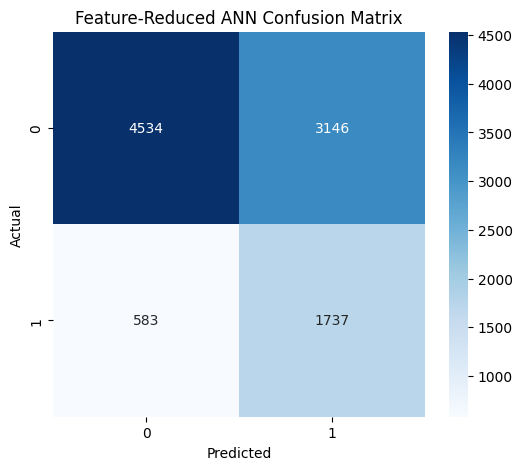

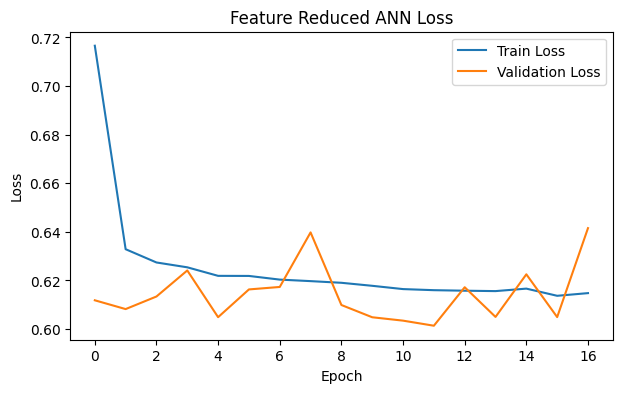

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

target_col = 'Repayment_Status_Encoded'

drop_cols = [target_col]
if 'Transaction_ID' in df.columns:
    drop_cols.append('Transaction_ID')

X_full = df.drop(columns=drop_cols).copy()
y_full = df[target_col].copy()

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_full, y_full,
    test_size=0.2,
    random_state=42,
    stratify=y_full
)

rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf.fit(X_train_full, y_train_full)

importance = pd.Series(rf.feature_importances_, index=X_train_full.columns)
importance = importance.sort_values(ascending=False)

print("\nTop 10 Features:\n", importance.head(10))
print("\nLeast Important Features:\n", importance.tail(10))

threshold = 0.018
low_importance = importance[importance < threshold].index.tolist()

print("\nDropping low-importance features:", low_importance)
print("Number of features removed:", len(low_importance))

X_reduced = X_full.drop(columns=low_importance)

print("\nOriginal feature count:", X_full.shape[1])
print("Reduced feature count:", X_reduced.shape[1])

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_reduced, y_full,
    test_size=0.2,
    random_state=42,
    stratify=y_full
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()

X_train[num_cols] = X_train[num_cols].astype(float)
X_val[num_cols] = X_val[num_cols].astype(float)
X_test[num_cols] = X_test[num_cols].astype(float)

scaler = StandardScaler()
X_train.loc[:, num_cols] = scaler.fit_transform(X_train[num_cols])
X_val.loc[:, num_cols] = scaler.transform(X_val[num_cols])
X_test.loc[:, num_cols] = scaler.transform(X_test[num_cols])

X_train_np = X_train.to_numpy().astype('float32')
X_val_np = X_val.to_numpy().astype('float32')
X_test_np = X_test.to_numpy().astype('float32')

y_train_np = y_train.to_numpy().astype('int32')
y_val_np = y_val.to_numpy().astype('int32')
y_test_np = y_test.to_numpy().astype('int32')

print("\nTrain distribution before SMOTE:", np.bincount(y_train_np))

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_np, y_train_np)

print("Train distribution after SMOTE:", np.bincount(y_train_smote))

ann_model = Sequential([
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(3, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = ann_model.fit(
    X_train_smote,
    y_train_smote,
    validation_data=(X_val_np, y_val_np),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

y_prob = ann_model.predict(X_test_np, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

rf_reduced_accuracy = accuracy_score(y_test_np, y_pred)

print("\nFEATURE-REDUCED ANN ACCURACY:", rf_reduced_accuracy)
print("\nClassification Report:\n", classification_report(y_test_np, y_pred, zero_division=0))

cm = confusion_matrix(y_test_np, y_pred)
print("\nConfusion Matrix:\n", cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Feature-Reduced ANN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

plt.figure(figsize=(7,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Feature Reduced ANN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

try:
    y_prob_train = ann_model.predict(X_train_smote, verbose=0)
    y_pred_train = np.argmax(y_prob_train, axis=1)
    collect_metrics("ANN (RF Feature Reduced)", y_train_smote.astype(int), y_pred_train.astype(int), notes="RF feature importance reduction + SMOTE; CV not run", split="Train")
    results_df = collect_metrics("ANN (RF Feature Reduced)", y_test_np.astype(int), y_pred.astype(int), notes="RF feature importance reduction + SMOTE; CV not run", split="Test")
    show_results()
except Exception as e:
    print("Could not add reduced-feature ANN results:", e)

In [62]:
results_table = show_results(sort_by="Accuracy", ascending=False)
results_table

,Model,Split,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,Precision_macro,Recall_macro,F1_macro,Notes,Precision_positive,Recall_positive,F1_positive,Precision_negative,Recall_negative,F1_negative,cv_metrics
0,k-NN,Train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,scaled features,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN
1,ANN (Binary),Train,0.862319,0.863978,0.862319,0.862162,0.863978,0.862319,0.862162,SMOTE + tuned ANN; CV not run,0.888549,0.828566,0.857510,0.839407,0.896073,0.866815,NaN
2,Random Forest,Train,0.815700,0.819693,0.815700,0.815123,0.819693,0.815700,0.815123,SMOTE on training set,0.855420,0.759823,0.804793,0.783966,0.871578,0.825454,NaN
3,Naive Bayes,Test,0.744500,0.707528,0.744500,0.718506,0.604849,0.568932,0.574127,GaussianNB,0.413284,0.241379,0.304762,0.796414,0.896484,0.843492,"{'CV_accuracy_mean': 0.7428750000000001, 'CV_A..."
4,Random Forest,Test,0.744000,0.727470,0.744000,0.734258,0.625866,0.608015,0.614495,SMOTE on training set,0.436306,0.354310,0.391056,0.815426,0.861719,0.837934,"{'CV_accuracy_mean': 0.7412750000000001, 'CV_A..."
5,Naive Bayes,Train,0.743650,0.706079,0.743650,0.717262,0.602658,0.567139,0.571988,GaussianNB,0.409690,0.237798,0.300927,0.795626,0.896481,0.843048,NaN
6,k-NN,Test,0.743500,0.694517,0.743500,0.706880,0.587528,0.547825,0.546911,scaled features,0.387923,0.182759,0.248462,0.787134,0.912891,0.845361,"{'CV_accuracy_mean': 0.7415, 'CV_Accuracy_std'..."
7,ANN (Binary),Test,0.728100,0.717089,0.728100,0.722073,0.607391,0.598265,0.601987,SMOTE + tuned ANN; CV not run,0.402730,0.356034,0.377946,0.812052,0.840495,0.826029,NaN
8,SVM,Train,0.699200,0.782718,0.699200,0.721407,0.652137,0.707084,0.651965,"RBF kernel, PCA n_components=20, train subset=...",0.411034,0.721640,0.523749,0.893240,0.692527,0.780181,NaN
9,ANN (RF Feature Reduced),Train,0.665086,0.667789,0.665086,0.663732,0.667789,0.665086,0.663732,RF feature importance reduction + SMOTE; CV no...,0.646494,0.728545,0.685071,0.689085,0.601628,0.642393,NaN
